In [1]:
import pickle
import pandas as pd
import joblib


In [2]:
model_path_prefix  = '../2_model_development/'
data_prefix = '../3_model_evaluation/model_evaluation_results_'
label = 'MP_label'
non_feature_cols = ['SMILES', 'MP', 'Type'] + [label] + ['MP_pred']
data_types = ['L', 'H', 'All']
model_types = ['LGB']

In [3]:
model_H = joblib.load(f"{model_path_prefix}best_model_LGB_H.joblib")
model_L = joblib.load(f"{model_path_prefix}best_model_LGB_L.joblib")
model_All = joblib.load(f"{model_path_prefix}best_model_LGB_All.joblib")



In [4]:
# check how many features are used in each model
print(f"Number of features in model_H: {len(model_H.feature_name_)}")
print(f"Number of features in model_L: {len(model_L.feature_name_)}")
print(f"Number of features in model_All: {len(model_All.feature_name_)}")

Number of features in model_H: 40
Number of features in model_L: 108
Number of features in model_All: 108


In [5]:
data_H  = pd.read_csv(data_prefix + "LGB_H.csv")
data_H = data_H[data_H['MP_label'] == 'H']

data_L  = pd.read_csv(data_prefix + "LGB_L.csv")
data_L = data_L[data_L['MP_label'] == 'L']

data_All = pd.read_csv(data_prefix + "LGB_All.csv")

# print dataset size and number of features
print(f"Dataset H: {data_H.shape[0]} samples, {data_H.shape[1] - len(non_feature_cols)} features")
print(f"Dataset L: {data_L.shape[0]} samples, {data_L.shape[1] - len(non_feature_cols)} features")
print(f"Dataset All: {data_All.shape[0]} samples, {data_All.shape[1] - len(non_feature_cols)} features")

Dataset H: 263 samples, 40 features
Dataset L: 4903 samples, 108 features
Dataset All: 5166 samples, 108 features


In [12]:
print("=== SHAP Analysis: Low-MP Model vs High-MP Model ===")

result_L, result_H, exp_L, exp_H = shap_analysis(
    model_L, model_H, data_L, data_H, n=10
)

=== SHAP Analysis: Low-MP Model vs High-MP Model ===


 97%|=================== | 4772/4903 [00:33<00:00]       

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 103.396898, while the model output was 92.339124. If this difference is acceptable you can set check_additivity=False to disable this check.

In [10]:
# Diagnostic: check feature overlap between model and data
for name, model, data in [('H', model_H, data_H), ('L', model_L, data_L)]:
    model_feats = set(model.feature_name_)
    data_feats  = set(data.columns) - set(non_feature_cols)
    missing = model_feats - data_feats
    extra   = data_feats - model_feats
    print(f"Model {name}: {len(model_feats)} features, data has {len(data_feats)} non-label cols")
    if missing:
        print(f"  ⚠️  Missing from data: {missing}")
    if extra:
        print(f"  ℹ️  Extra in data (ignored): {len(extra)} cols")

Model H: 40 features, data has 40 non-label cols
Model L: 108 features, data has 108 non-label cols


In [31]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams


def shap_analysis(model_L, model_H, data_L, data_H, n=10):

    model_class_L = type(model_L).__name__
    model_class_H = type(model_H).__name__

    for mc in (model_class_L, model_class_H):
        if mc not in ('RandomForestRegressor', 'XGBRegressor', 'LGBMRegressor'):
            raise ValueError(f"Unsupported model type: {mc!r}")

    def _compute(model, data):
        X        = data.drop(columns=non_feature_cols, errors='ignore')
        exp      = shap.TreeExplainer(model)
        sv       = exp.shap_values(X)
        mean_abs = np.abs(sv).mean(axis=0)
        top_idx  = np.argsort(mean_abs)[::-1][:n]
        feats    = X.columns[top_idx].tolist()
        vals     = mean_abs[top_idx]
        return X, sv, feats, vals, exp

    XL, svL, featsL, valsL, expL = _compute(model_L, data_L)
    XH, svH, featsH, valsH, expH = _compute(model_H, data_H)

    setL, setH = set(featsL), set(featsH)

    # ── Colours ──────────────────────────────────────────────────────
    CL, CH           = '#2166AC', '#D6604D'
    CL_edge, CH_edge = '#1A4A7A', '#A03020'
    C_BOTH           = '#555555'

    def _label_color(feat, own_color):
        if feat in setL and feat in setH:
            return C_BOTH
        return own_color

    rcParams.update({
        'font.family'      : 'sans-serif',
        'font.sans-serif'  : ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size'        : 10,
        'axes.linewidth'   : 0.8,
        'xtick.major.width': 0.6,
        'ytick.major.width': 0.6,
    })

    # Shared x limit
    xmax = max(valsL.max(), valsH.max()) * 1.12

    panel_h = max(4, n * 0.45)
    fig = plt.figure(figsize=(16, panel_h), facecolor='white', dpi=150)
    gs  = fig.add_gridspec(1, 2, wspace=0.08, top=0.88, bottom=0.12,
                           left=0.05, right=0.95)
    axL = fig.add_subplot(gs[0, 0])   # left  – model_L / data_L
    axH = fig.add_subplot(gs[0, 1])   # right – model_H / data_H

    bh = 0.62
    # y positions: most important (index 0) at the top → highest y value
    yL = np.arange(len(featsL) - 1, -1, -1)
    yH = np.arange(len(featsH) - 1, -1, -1)
    gap = xmax * 0.025   # small offset from the bar tip

    # ── Left panel – model_L, bars LEFT, labels at LEFT tip ────────────
    axL.barh(yL, valsL, height=bh, color=CL, edgecolor=CL_edge,
             linewidth=0.5, zorder=3)
    axL.set_xlim(0, xmax)
    axL.invert_xaxis()                 # bars extend leftward; x=0 is on the right
    axL.set_ylim(-0.6, len(featsL) - 0.4)
    axL.set_yticks([])                 # no y-tick labels; we annotate manually
    axL.tick_params(axis='x', labelsize=9, length=3)
    axL.set_xlabel('Mean |SHAP value|', fontsize=11, labelpad=5)
    axL.grid(axis='x', linestyle='--', linewidth=0.45, alpha=0.55, zorder=0)
    axL.spines['top'].set_visible(False)
    axL.spines['left'].set_visible(False)
    axL.spines['right'].set_linewidth(0.7)
    axL.spines['bottom'].set_linewidth(0.7)
    axL.set_title(f'Low-MP Model  ({model_class_L})', fontsize=12, fontweight='bold',
                  color=CL, pad=9)

    # Feature names at the left tip
    for yi, (feat, val) in zip(yL, zip(featsL, valsL)):
        axL.text(val + gap, yi, feat,
                 ha='right', va='center', fontsize=9, fontweight='bold',
                 color=_label_color(feat, CL), zorder=6)

    # ── Right panel – model_H, bars RIGHT, labels at RIGHT tip ──────────
    axH.barh(yH, valsH, height=bh, color=CH, edgecolor=CH_edge,
             linewidth=0.5, zorder=3)
    axH.set_xlim(0, xmax)
    axH.set_ylim(-0.6, len(featsH) - 0.4)
    axH.set_yticks([])
    axH.tick_params(axis='x', labelsize=9, length=3)
    axH.set_xlabel('Mean |SHAP value|', fontsize=11, labelpad=5)
    axH.grid(axis='x', linestyle='--', linewidth=0.45, alpha=0.55, zorder=0)
    axH.spines['top'].set_visible(False)
    axH.spines['right'].set_visible(False)
    axH.spines['left'].set_linewidth(0.7)
    axH.spines['bottom'].set_linewidth(0.7)
    axH.set_title(f'High-MP Model  ({model_class_H})', fontsize=12, fontweight='bold',
                  color=CH, pad=9)

    # Feature names at the right tip
    for yi, (feat, val) in zip(yH, zip(featsH, valsH)):
        axH.text(val + gap, yi, feat,
                 ha='left', va='center', fontsize=9, fontweight='bold',
                 color=_label_color(feat, CH), zorder=6)

    # ── Title ────────────────────────────────────────────────────────
    fig.suptitle(
        f'Top-{n} SHAP Feature Importances  ·  Low-MP vs High-MP',
        fontsize=14, fontweight='bold', color='#222222', y=0.975
    )

    plt.show()

    # ── Attach SHAP values back to original DataFrames ───────────────
    def _attach(data, X, sv):
        df_s = pd.DataFrame(sv, columns=[f'shap_{c}' for c in X.columns],
                            index=data.index)
        return pd.concat([data, df_s], axis=1)

    return _attach(data_L, XL, svL), _attach(data_H, XH, svH), expL, expH

=== SHAP Analysis: Low-MP Model vs High-MP Model ===


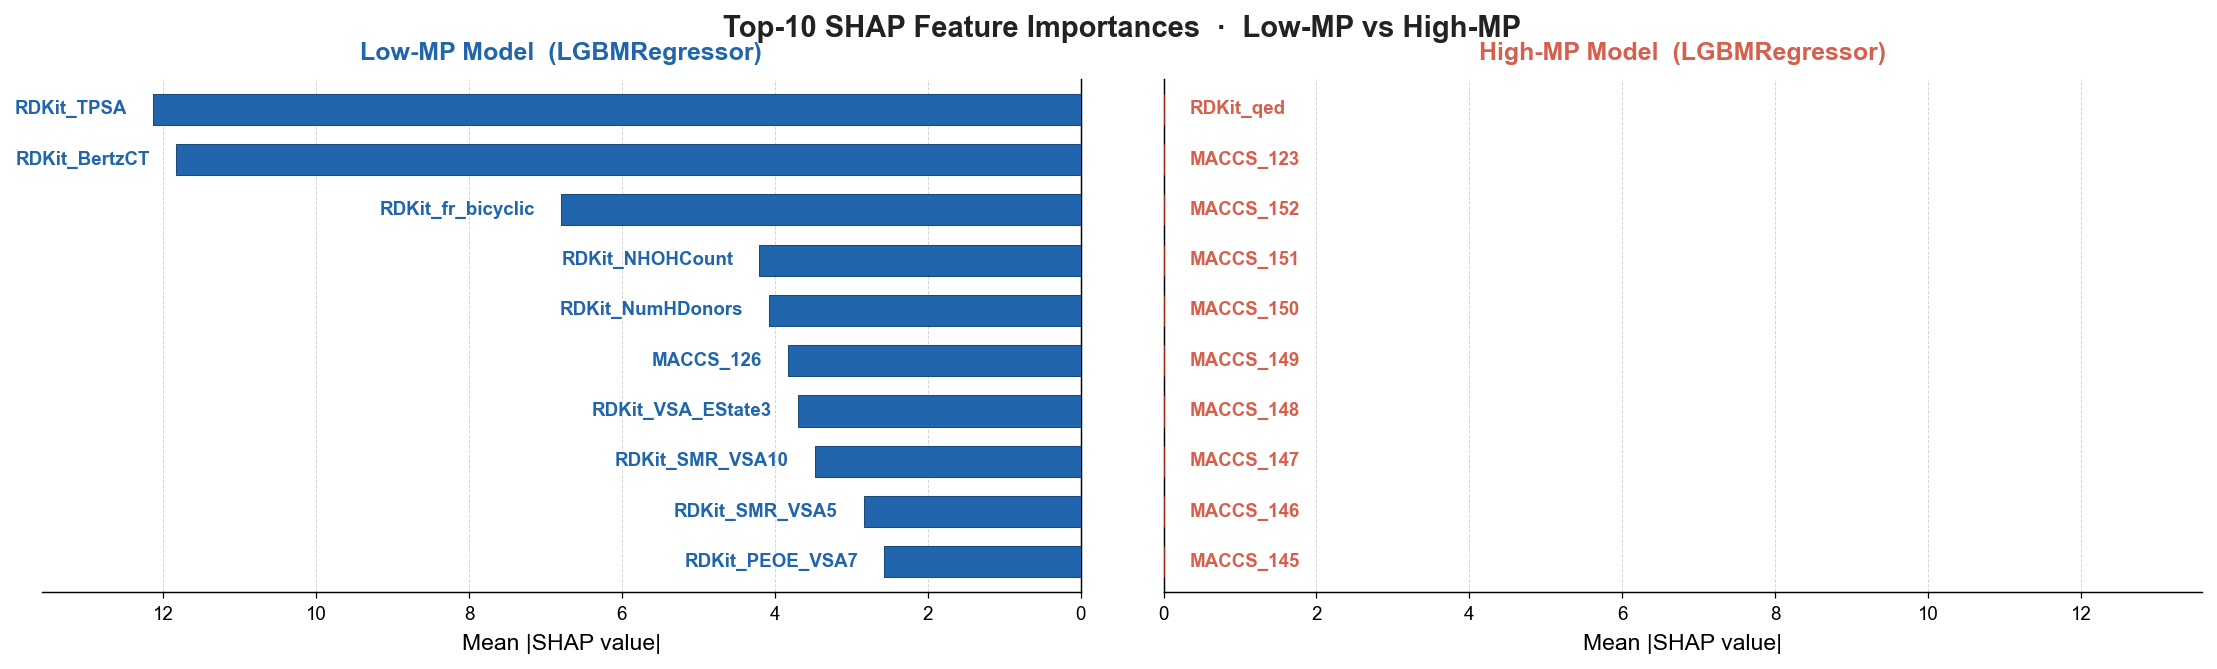

In [32]:
print("=== SHAP Analysis: Low-MP Model vs High-MP Model ===")

result_L, result_H, exp_L, exp_H = shap_analysis(
    model_L, model_H, data_L, data_H, n=10
)

In [29]:
# Deep diagnostic on model_H
print("=== Deep Diagnostic: model_H ===")
print(f"Number of trees: {model_H.booster_.num_trees()}")
print(f"Number of features: {model_H.n_features_in_}")
print(f"Best iteration: {getattr(model_H, 'best_iteration_', 'N/A')}")
print(f"Best score: {getattr(model_H, 'best_score_', 'N/A')}")
print(f"Objective: {model_H.get_params().get('objective', 'N/A')}")
print(f"n_estimators: {model_H.get_params().get('n_estimators', 'N/A')}")
print()

# Check if the model actually has any splits
model_dump = model_H.booster_.dump_model()
tree_info = model_dump['tree_info']
print(f"Number of trees in dump: {len(tree_info)}")
if len(tree_info) > 0:
    first_tree = tree_info[0]['tree_structure']
    print(f"First tree structure keys: {first_tree.keys()}")
    # A tree with no splits will only have 'leaf_value'
    if 'split_feature' not in first_tree:
        print("  ⚠️  First tree has NO splits — it's just a leaf!")
        print(f"  leaf_value: {first_tree.get('leaf_value')}")
    else:
        print(f"  First tree splits on feature: {first_tree['split_feature']}")

print()

# Test predict with numpy array (bypasses any column name matching)
X_H = data_H.drop(columns=non_feature_cols, errors='ignore')
X_H = X_H.reindex(columns=model_H.feature_name_, fill_value=0)

preds_df = model_H.booster_.predict(X_H)
preds_np = model_H.booster_.predict(X_H.values)

print(f"Predict with DataFrame: {preds_df.min():.4f} – {preds_df.max():.4f}")
print(f"Predict with numpy:     {preds_np.min():.4f} – {preds_np.max():.4f}")
print(f"Same results: {np.allclose(preds_df, preds_np)}")

# Also check: is model_H actually a classifier disguised as regression?
print(f"\n_n_classes: {getattr(model_H, '_n_classes', 'N/A')}")
print(f"_objective: {getattr(model_H, '_objective', 'N/A')}")
print(f"class name: {type(model_H).__name__}")

=== Deep Diagnostic: model_H ===
Number of trees: 1
Number of features: 40
Best iteration: None
Best score: defaultdict(<class 'collections.OrderedDict'>, {})
Objective: None
n_estimators: 435

Number of trees in dump: 1
First tree structure keys: dict_keys(['leaf_value', 'leaf_count'])
  ⚠️  First tree has NO splits — it's just a leaf!
  leaf_value: 282.7331578304893

Predict with DataFrame: 282.7332 – 282.7332
Predict with numpy:     282.7332 – 282.7332
Same results: True

_n_classes: None
_objective: regression
class name: LGBMRegressor


In [30]:
# Check model_H hyperparameters vs model_L
print("=== Hyperparameter comparison ===")
params_H = model_H.get_params()
params_L = model_L.get_params()

for key in sorted(set(list(params_H.keys()) + list(params_L.keys()))):
    vH = params_H.get(key)
    vL = params_L.get(key)
    flag = "  ⚠️" if vH != vL else ""
    print(f"  {key:30s}  L={vL!s:>15s}  H={vH!s:>15s}{flag}")

=== Hyperparameter comparison ===
  boosting_type                   L=           gbdt  H=           gbdt
  class_weight                    L=           None  H=           None
  colsample_bytree                L=0.8911973272498119  H=0.9024330133319707  ⚠️
  importance_type                 L=          split  H=          split
  learning_rate                   L=0.04716983977518968  H=0.2017268796559709  ⚠️
  max_depth                       L=             12  H=              6  ⚠️
  min_child_samples               L=             19  H=             48  ⚠️
  min_child_weight                L=          0.001  H=          0.001
  min_split_gain                  L=            0.0  H=            0.0
  n_estimators                    L=            315  H=            435  ⚠️
  n_jobs                          L=             -1  H=             -1
  num_leaves                      L=             20  H=             37  ⚠️
  objective                       L=           None  H=           None
  rand